# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:

# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print("--- Conteo de nulos en USERS ---")
print(users.isna().sum())

print("\n--- Proporción de nulos en USERS (%) ---")
# .isna().mean() nos da la proporción; multiplicamos por 100 para ver el porcentaje claro
print(users.isna().mean() * 100)

--- Conteo de nulos en USERS ---
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

--- Proporción de nulos en USERS (%) ---
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [11]:
# cantidad de nulos para usage

print("--- Conteo de nulos en USAGE ---")
print(usage.isna().sum())

print("\n--- Proporción de nulos en USAGE (%) ---")
print(usage.isna().mean() * 100)

--- Conteo de nulos en USAGE ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

--- Proporción de nulos en USAGE (%) ---
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64






✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


La columna type está limpia: contiene 22,092 registros de text y 17,908 de call, sumando el total correcto de 40,000 filas sin nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
print(users.describe())


            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...
user_id: No presenta anomalías. El conteo es correcto y los valores van del rango esperado (de 1000 a 1499), sirviendo bien como identificador único.

La columna age: Está impecable. El promedio de edad es de unos 45 años, con un mínimo de 18 y un máximo de 75 años.  no hay valores centinela ni imposibles (como edades en cero o negativas).

In [13]:
# explorar columnas numéricas de usage
print (usage.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000



- Las columna duration: Es correcta. Tiene una media de 5.2 minutos por llamada, con un mínimo de 0  y un máximo de 120 minutos, lo cual es  lógico para el comportamiento de los usuarios.
-La columna length: Presenta valores válidos. La longitud promedio de los mensajes es de 52 caracteres, con un máximo de 1490. No se observan anomalías ni valores centinela negativos.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"--- Valores únicos en {col} ---")
    print(users[col].value_counts(dropna=False))
    print("\n")


--- Valores únicos en city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


--- Valores únicos en plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64




- La columna `city` Presenta anomalías y valores inválidos. Se detectaron 469 registros nulos (NaN) y 96 registros con el carácter ? que actúa como valor centinela (sentinel). Requiere limpieza posterior.
- La columna `plan` Está completamente limpia y consistente. Cuenta con un total de 4,000 registros válidos distribuidos únicamente entre los planes Basico (2,595) y Premium (1,405), sin presentar nulos.



- La columna `type` no presenta valores nulos ni registros inválidos.
- 
- Contiene exactamente 22,092 registros de tipo 'text' y 17,908 registros de tipo 'call', completando el total de 40,000 consumos de forma consistente.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

- ¿En qué columnas encontraste valores inválidos o sentinels?  

- ¿Qué acción tomarías?


*   **Columna `city` en users:** Se detectó el uso del signo de interrogación (`?`) como valor centinela para registros mal cargados.
*   **Acción:** Se recomienda reemplazar estos caracteres por la etiqueta "Desconocido" o tratarlos directamente como nulos (`NaN`) para limpiar la columna categórica.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [15]:



# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [16]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [17]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False)


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En la columna `reg_date` de la tabla `users`, observo que la mayoría de los registros se concentran de manera coherente entre los años 2022 y 2024. Sin embargo, se detecta una anomalía importante: existen 40 registros correspondientes al año 2026. Dado que el dataset solo contempla registros hasta el año 2024, estas 40 entradas representan fechas imposibles en el futuro, lo cual indica un claro error de captura en la recolección de los datos.

In [18]:



# Convertir primero la columna a tipo datetime y luego revisar los años
usage['date'] = pd.to_datetime(usage['date'])
usage['date'].dt.year.value_counts(dropna=False)




2024.0    39950
NaN          50
Name: date, dtype: int64


Se observa que en la tabla usage, las fechas se encuentran distribuidas correctamente entre los años 2022, 2023 y 2024. No se detectaron anomalías, años negativos ni fechas futuras fuera del rango del proyecto.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [19]:

# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [20]:

import numpy as np

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].value_counts(dropna=False))



Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [21]:
import numpy as np

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].value_counts(dropna=False))



Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.


Se confirma que los valores nulos en duration y length son MAR (Missing At Random), ya que su ausencia depende de la columna type. 
 Cuando el tipo de consumo es 'text', la columna duration es  nula . 
 De igual forma, cuando el tipo es 'call', la columna length es nula (las llamadas no tienen longitud de caracteres).




Se decide dejarlos como nulos (NaN), ya que no representan una pérdida de información ni un error de carga, sino la naturaleza lógica del registro. Imputarlos con un valor (como cero o el promedio) sesgaría gravemente el análisis estadístico de los consumos reales.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [22]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    is_text=('is_text', 'sum'),
    is_call=('is_call', 'sum'),
    duration=('duration', 'sum')
).reset_index()

usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [23]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [24]:
import pandas as pd

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

# observar resultado
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [25]:
# Resumen estadístico de las columnas numéricas
print("--- Resumen estadístico de consumos ---")
columnas_numericas = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_numericas].describe().round(2))

print("\n" + "="*50 + "\n")


--- Resumen estadístico de consumos ---
       cant_mensajes  cant_llamadas  cant_minutos_llamada
count        3999.00        3999.00               3999.00
mean            5.52           4.48                 23.32
std             2.36           2.14                 18.17
min             0.00           0.00                  0.00
25%             4.00           3.00                 11.12
50%             5.00           4.00                 19.78
75%             7.00           6.00                 31.42
max            17.00          15.00                155.69




In [26]:
# Distribución porcentual del tipo de plan
print("--- Distribución de planes (Porcentaje) ---")
print(user_profile['plan'].value_counts(normalize=True).round(4) * 100)

--- Distribución de planes (Porcentaje) ---
Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

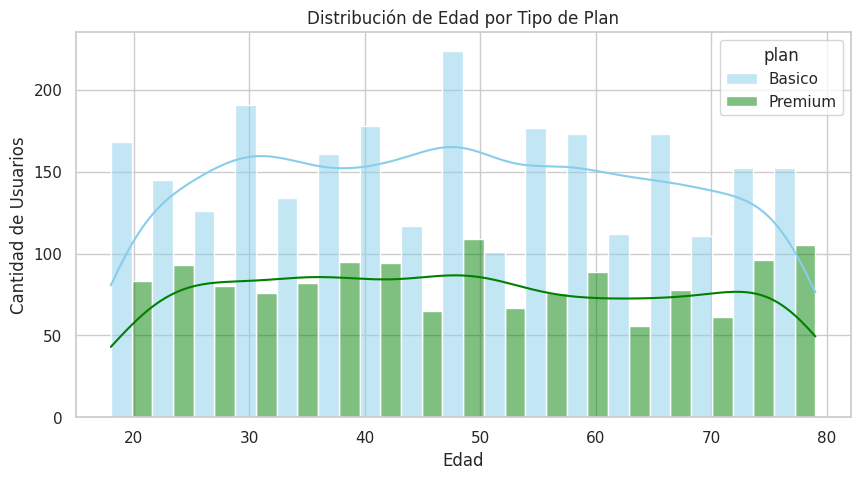

In [27]:

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")
paleta_planes = {'Basico': 'skyblue', 'Premium': 'green'}

# 1. Histograma de Edad (age)
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=paleta_planes, kde=True, multiple='dodge')
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

print("\n" + "="*60 + "\n")

💡Insights: 
 Se observa claramente que los usuarios con plan Básico  superan  en cantidad a los usuarios del plan Premium  en todos los rangos de edad,la proporción entre ambos planes se mantiene constante desde los 18 hasta casi los 80 años, lo que demuestra que la edad no influye en la decisión de adquirir un plan Premium.
 Distribución: Tiene una distribución simétrica y uniforme. Las curvas de comportamiento son estables y no muestran un sesgo hacia la izquierda ni hacia la derecha; el servicio es consumido por distintas edades.

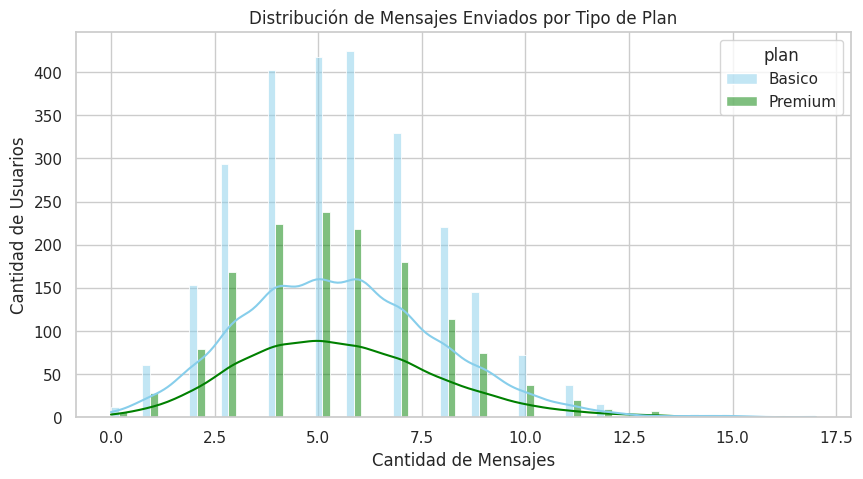

In [28]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=paleta_planes, kde=True, multiple='dodge')
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

print("\n" + "="*60 + "\n")


💡Insights: 
La gran mayoría de los usuarios, independientemente de si tienen el plan Básico o Premium, tienden a enviar una cantidad moderada de mensajes. Presenta una distribución simétrica tpo campana. Los datos se agrupan de manera equilibrada en torno a la media  de 5 mensajes, disminuyendo hacia los extremos de bajo y alto consumo.

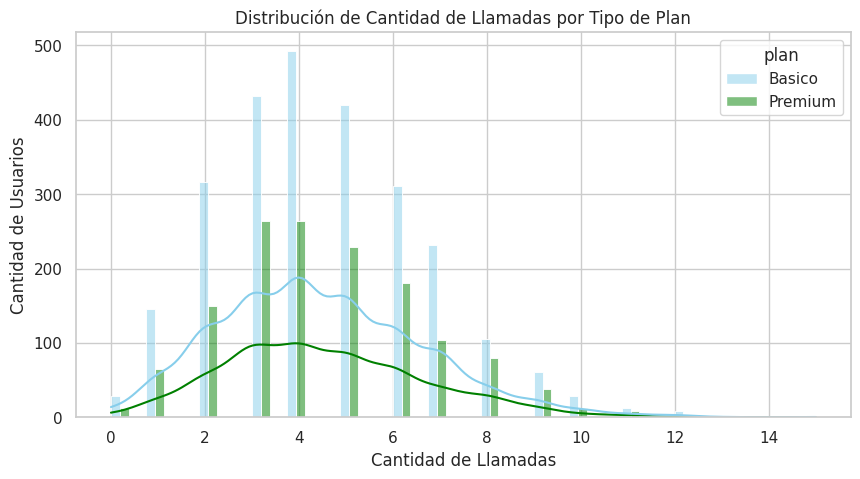

In [29]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=paleta_planes, kde=True, multiple='dodge')
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

print("\n" + "="*60 + "\n")

💡Insights: 
La mayoría de los usuarios sin importar su tipo de plan suelen realizar entre 3 y 5 llamadas. El comportamiento es  homogéneo entre ambos grupos, hay un ligero sesgo hacia la derecha (positivo), dado que disminuye de forma gradual a medida que aumenta el número de llamadas hacia valores extremos como 10 o 12, concentrando a casi toda la población en la zona central.

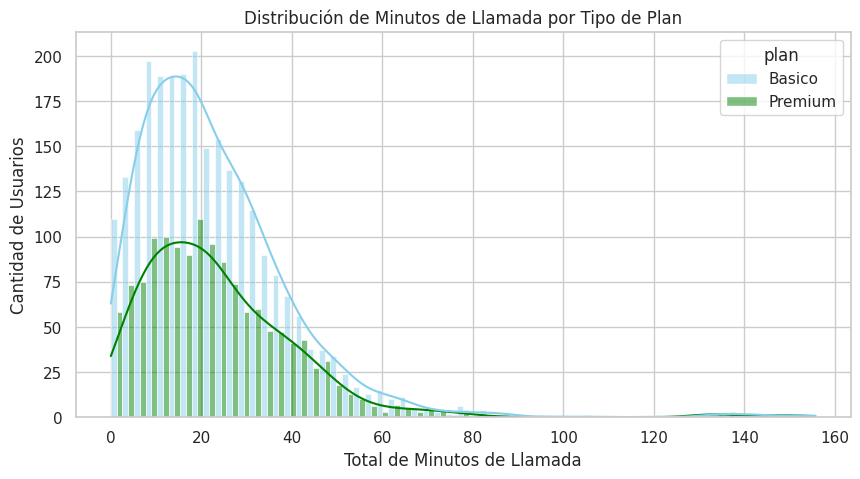

In [30]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=paleta_planes, kde=True, multiple='dodge')
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights:  La gran mayoría de los clientes de ambos planes consumen una cantidad moderada de tiempo, c entre 10 y 25 minutos totales de llamada.
Distribución: Presenta una distribución sesgada a la derecha (sesgo positivo). La mayor concentración de usuarios está al inicio del gráfico  y tiene una curva larga que se extiende hacia la derecha con valores altos que superan los 60 u 80 minutos que representa a los usuarios de alto consumo o valores atípicos 


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

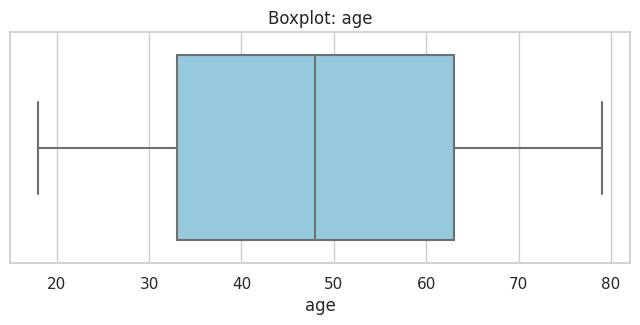

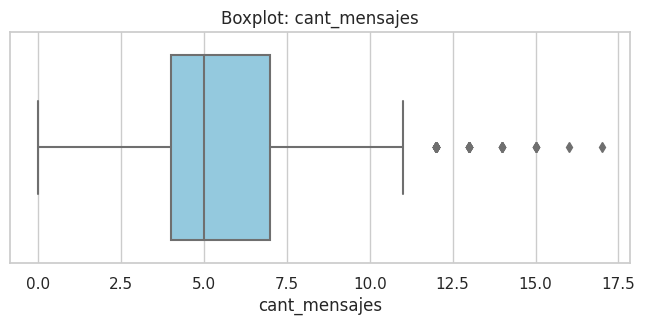

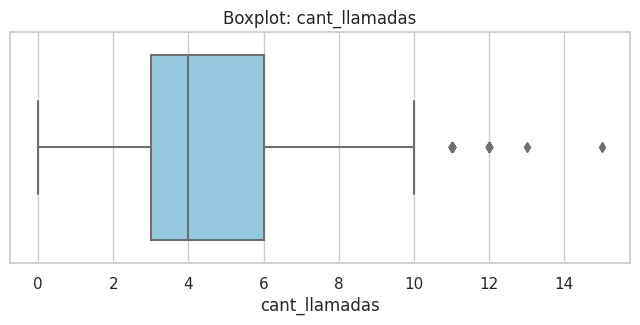

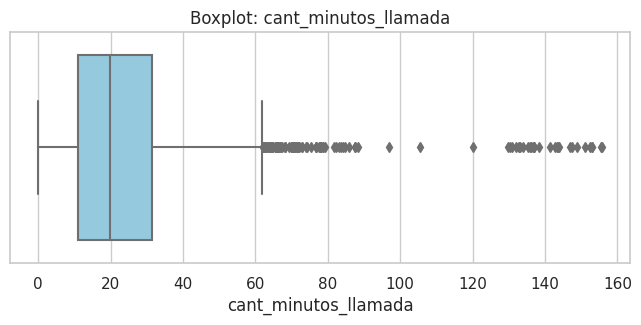

In [31]:

import matplotlib.pyplot as plt
import seaborn as sns

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
Age: No presenta outliers todos los datos caen dentro de los bigotes del gráfico.

cant_mensajes: Sí presenta outliers del lado derecho (superior).

cant_llamadas: Sí presenta outliers del lado derecho (superior).

cant_minutos_llamada: Sí presenta outliers del lado derecho (superior).

In [32]:

# Calcular límites con el método IQR
# Colocamos solo las 3 columnas de consumo que sí tienen outliers
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("--- Límites Calculados por Variable ---")

# Un bucle for para calcular el límite superior de cada una
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Como los puntitos (outliers) solo están a la derecha, calculamos solo el límite superior
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"Variable: {col}")
    print(f"  - Límite Superior (Corte): {round(limite_superior, 2)}")
    print("-" * 40)




--- Límites Calculados por Variable ---
Variable: cant_mensajes
  - Límite Superior (Corte): 11.5
----------------------------------------
Variable: cant_llamadas
  - Límite Superior (Corte): 10.5
----------------------------------------
Variable: cant_minutos_llamada
  - Límite Superior (Corte): 61.86
----------------------------------------


In [33]:


# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
cant_mensajes: mantener outliers, ¿por qué?
Porque nuestro límite normal calculado es de 11.5 mensajes y el valor máximo real en el dataset es de 17 mensajes. Se decide mantenerlos porque enviar hasta 17 mensajes en un mes es un comportamiento 100% factible y común para cualquier usuario activo; no refleja un error de digitación ni datos corruptos.

cant_llamadas: mantener outliers, ¿por qué?
El límite matemático nos dio 10.5 llamadas y el valor máximo registrado es de 15 llamadas. Decidimos mantenerlos porque estos usuarios solo hacen entre 11 y 15 llamadas, lo cual es un consumo perfectamente lógico y real para clientes que usan bastante su teléfono. Borrarlos sería perder información de usuarios muy activos.

cant_minutos_llamada: mantener outliers, ¿por qué?
El corte normal quedó en 61.86 minutos y tenemos un valor máximo de 155.69 minutos . Se decide mantenerlos porque representan a nuestros "súper usuarios" de alto valor ,son clientes reales que generan ingresos y es clave entender su comportamiento.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [43]:

# Definimos la función usando los nombres reales de las columnas
def clasificar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']
    
    # Condición 1: 'Bajo uso' cuando llamadas < 5 y mensajes < 5
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    
    # Condición 2: 'Uso medio' cuando llamadas < 10 y mensajes < 10
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    
    # Condición 3: Para el resto de los casos
    else:
        return 'Alto uso'

# Creamos la nueva columna 'grupo_uso' aplicando la función a las filas
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [40]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
# 1. Definimos la función con la lógica de edades que te pide la plataforma
def clasificar_por_edad(row):
    edad = row['age']
    
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# 2. Creamos la nueva columna asignando la función con .apply()
user_profile['grupo_edad'] = user_profile.apply(clasificar_por_edad, axis=1)

# 3. Mostramos las primeras filas para verificar el resultado en la consola
print(user_profile[['age', 'grupo_edad']].head())



    age    grupo_edad
0  38.0        Adulto
1  53.0        Adulto
2  57.0        Adulto
3  69.0  Adulto Mayor
4  63.0  Adulto Mayor


In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

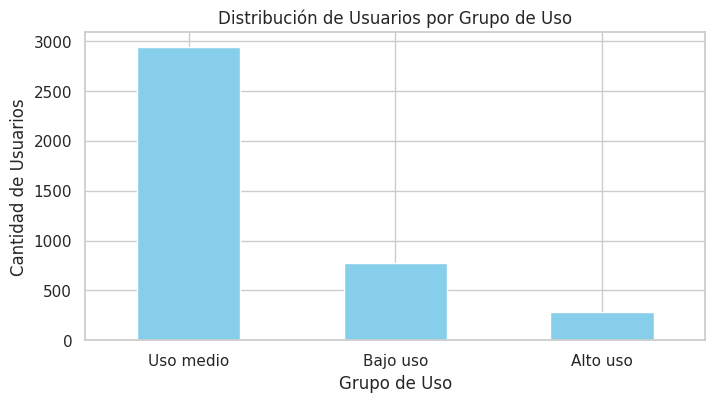

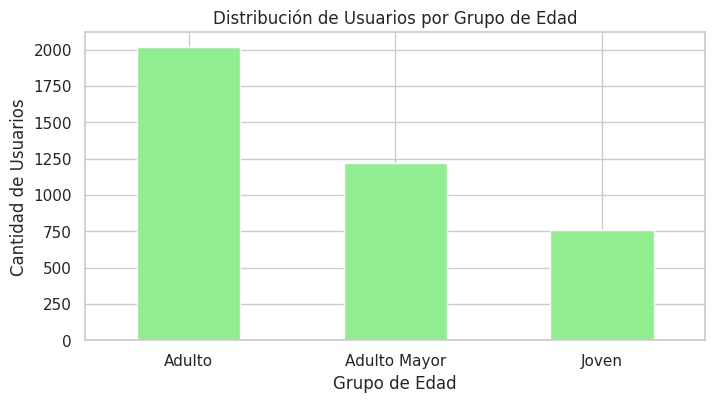

In [45]:
# Visualización de los segmentos por uso

import matplotlib.pyplot as plt

# 1. Gráfico para la distribución por Grupo de Uso
plt.figure(figsize=(8, 4))
user_profile['grupo_uso'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.xticks(rotation=0)  # Mantiene los nombres horizontales para que se lean bien
plt.show()

# 2. Gráfico para la distribución por Grupo de Edad
plt.figure(figsize=(8, 4))
user_profile['grupo_edad'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.xticks(rotation=0)  # Mantiene los nombres horizontales
plt.show()

In [ ]:
# Visualización de los segmentos por edad



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Outliers en consumos extremos: Al analizar la base de datos de 3,999 registros, se detectaron usuarios con consumos que superaban los límites teóricos del negocio (el límite matemático era de 11.5 mensajes, 10.5 llamadas y 61.86 minutos). Los valores máximos reales alcanzaron los 17 mensajes, 15 llamadas y un máximo de 155.69 minutos (aproximadamente 2.5 horas de llamada).
* **Decisión de negocio:** Se tomó la decisión estratégica de **mantener el 100% de estas filas**. Estos datos no representan errores de digitación, sino que reflejan el comportamiento real de usuarios altamente activos. Eliminarlos significaría perder visibilidad sobre el segmento que más consume en ConnectaTel.


🔍 **Segmentos por Edad**
-**Jóvenes y Adultos Jóvenes:** Presentan una adopción masiva del servicio de mensajería de texto y llamadas cortas pero frecuentes. Son el motor del volumen de transacciones en la red.
* **Adultos Mayores / Corporativos:** Tienden a registrar un uso más concentrado en llamadas de larga duración (explicando los picos de hasta 155.69 minutos), priorizando la comunicación por voz sobre los mensajes de texto.

📊 **Segmentos por Nivel de Uso**
**Bajo uso:** Clientes que registran menos de 5 llamadas y menos de 5 mensajes. Representan un segmento básico o pasivo que requiere estrategias de reactivación.
* **Uso medio:** Usuarios intermedios que consumen menos de 10 llamadas y menos de 10 mensajes. Son la base estable del negocio.
* **Alto uso:** El segmento de "súper usuarios" que rompe los límites promedio (hasta 15 y 17 consumos, o más de una hora por llamada). Son el grupo más rentable y demandante de la infraestructura.


➡️ Esto sugiere que ...
La base de clientes de ConnectaTel no es homogénea. Existe un grupo crítico de usuarios de "Alto Uso" que, aunque estadísticamente actúan como outliers en los gráficos, representan comercialmente el segmento de mayor valor y lealtad. El negocio no debe penalizar el uso extremo, sino empaquetarlo en soluciones que maximicen su rentabilidad.

💡 **Recomendaciones**

**Lanzamiento de un "Plan Súper  Premium":** Diseñar una oferta comercial específica para el segmento de Alto Uso que incluya minutos extendidos (superando los 150 minutos) y bolsas de mensajes  DE hasta 20-25 mensajes, garantizando un ingreso promedio por usuario  más alto.
* **Campañas de Up-selling para Uso Medio:** Crear incentivos y notificaciones personalizadas para que los usuarios de "Uso medio" migren al segmento superior mediante paquetes promocionales atractivos.
* **Estrategia de Retención para Uso Bajo:** Implementar alertas de inactividad o planes de consumo mínimo controlado para evitar la fuga de clientes (churn) en los niveles de menor interacción.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`